### ReAct Agent

In [ ]:
from rich import print
import os
from dotenv import load_dotenv
load_dotenv()

In [ ]:
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["LANGSMITH_API_KEY"]=os.getenv("LANGSMITH_API_KEY")

In [ ]:
from langchain_core.documents import Document

In [ ]:
rfq_docs = [

    Document(
        page_content="""
RFQ Requirement R1

The solution must support Single Sign-On (SSO)
using SAML 2.0.

Weight: Mandatory
"""
    ),

    Document(
        page_content="""
RFQ Requirement R2

The bidder must provide evidence of SOC2 Type II
certification.

Weight: Mandatory
"""
    ),

    Document(
        page_content="""
RFQ Requirement R3

The platform must support multi-tenancy.

Weight: High Priority
"""
    ),

    Document(
        page_content="""
RFQ Requirement R4

System should process 1000 requests per second.

Weight: High Priority
"""
    )
]

In [ ]:
bidder_docs = [

    Document(
        page_content="""
Vendor A Technical Proposal

The platform supports SAML 2.0
Single Sign-On integration.

Supported providers:

- Okta
- Azure AD
- Ping Identity
"""
    ),

    Document(
        page_content="""
Vendor A Security Response

The company maintains SOC2 Type II
compliance and undergoes annual audits.
"""
    ),

    Document(
        page_content="""
Vendor A Architecture Document

The platform is designed using a
multi-tenant architecture.

Tenant isolation is achieved
through logical partitioning.
"""
    ),

    Document(
        page_content="""
Vendor A Performance Report

The platform has been benchmarked
at 1200 requests per second.
"""
    )
]

In [ ]:
all_docs = rfq_docs + bidder_docs

In [ ]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

In [ ]:
from langchain_community.vectorstores import FAISS

vectorstore=FAISS.from_documents(documents=all_docs,embedding=embeddings)

In [ ]:
retriever=vectorstore.as_retriever(k=3)

In [ ]:
from langchain_core.tools import tool

In [ ]:
@tool
def search_tender_documents(query: str) -> str:
    """
    Search RFQ and bidder documents.
    """

    docs = retriever.invoke(query)

    result = "\n\n".join(
        doc.page_content
        for doc in docs
    )

    return result

In [ ]:
from typing import Annotated, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    # add_messages reducer: new messages are appended, not replaced
    messages: Annotated[list[BaseMessage], add_messages]

In [ ]:
from langchain.chat_models import init_chat_model

llm=init_chat_model(model="groq:meta-llama/llama-4-scout-17b-16e-instruct")

In [ ]:
tools = [search_tender_documents]

llm_with_tools = llm.bind_tools(tools)

In [ ]:
SYSTEM_PROMPT = """
You are an expert procurement and tender
evaluation assistant.

You answer RFQ evaluation questions.

Rules:

1. Use search_tender_documents whenever
   evidence is required.

2. Never invent information.

3. Quote supporting evidence.

4. If requirement is not met,
   clearly mention the gap.

5. Focus on compliance assessment.
"""

In [ ]:
def agent_node(state: AgentState):

    messages = state["messages"]

    response = llm_with_tools.invoke(
        [
            ("system", SYSTEM_PROMPT),
            *messages
        ]
    )

    return {
        "messages": [response]
    }

In [ ]:
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools)

In [ ]:
from langgraph.prebuilt import tools_condition
from langgraph.graph import StateGraph, START, END

graph = StateGraph(AgentState)

graph.add_node(
    "agent",
    agent_node
)

graph.add_node(
    "tools",
    tool_node
)

graph.set_entry_point("agent")

# graph.add_conditional_edges(
#     "agent",
#     tools_condition,
#     {
#         "tools": "tools",
#         END: END
#     }
# )

graph.add_conditional_edges(
    "agent",
    tools_condition
)

graph.add_edge(
    "tools",
    "agent"
)

app = graph.compile()

In [ ]:
app

In [ ]:
from langchain_core.messages import HumanMessage

response = app.invoke(
    {
        "messages": [
            HumanMessage(
                content="""
Does Vendor A satisfy the SSO
requirement?
"""
            )
        ]
    }
)

print(
    response["messages"][-1].content
)

---

In [28]:

import os
from typing import Annotated, TypedDict, Any
from rich import print
from dotenv import load_dotenv

load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

from langchain_core.documents import Document
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, START, END

# --- 1. Mock Data ---
rfq_docs = [
    Document(page_content="RFQ Requirement R1: The solution must support Single Sign-On (SSO) using SAML 2.0. [Weight: Mandatory]", metadata={"source":
"rfq_requirements.pdf"}),
    Document(page_content="RFQ Requirement R2: The bidder must provide evidence of SOC2 Type II certification. [Weight: Mandatory]", metadata={"source": "rfq_requirements.pdf"}),
    Document(page_content="RFQ Requirement R3: The platform must support multi-tenancy. [Weight: High Priority]", metadata={"source": "rfq_requirements.pdf"}),
]
bidder_docs = [
    Document(page_content="Vendor A Proposal: The platform supports SAML 2.0 Single Sign-On integration using Okta and Azure AD.", metadata={"source":
"vendor_a_proposal.pdf"}),
    Document(page_content="Vendor A Proposal: Vendor A is SOC2 Type II compliant and undergoes annual audits.", metadata={"source": "vendor_a_security.pdf"}),
]
all_docs = rfq_docs + bidder_docs

# --- 2. RAG Setup ---
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(documents=all_docs, embedding=embeddings)
retriever = vectorstore.as_retriever(k=3)

# --- 3. Custom State with Document Tracking & Step Count ---
def merge_documents(left: list[Any] | None, right: list[Any] | None) -> list[Any]:
    return (left or []) + (right or [])

class AdvancedAgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    step_count: int  # Prevents infinite loops
    documents: Annotated[list[dict], merge_documents]  # Automatically collects retrieved source docs

# --- 4. Tool with Automatic Source Logging ---
@tool
def search_tender_documents(query: str, state: AdvancedAgentState) -> str:
    """Search RFQ requirements and bidder proposals for evidence."""
    docs = retriever.invoke(query)

    formatted_chunks = []
    new_docs = []

    # We retrieve the documents and assign them a dynamic index
    for idx, doc in enumerate(docs, start=1):
        source = doc.metadata.get("source", "unknown")
        formatted_chunks.append(f"[{idx}] (Source: {source}): {doc.page_content}")

        # Save to state["documents"] so we can print citations at the very end
        new_docs.append({"text": doc.page_content, "source": source})

    # We update the state explicitly so the graph retains these citations
    state["documents"].extend(new_docs)
    return "\n\n".join(formatted_chunks)

# --- 5. Nodes and Graph ---
from langchain.chat_models import init_chat_model
llm = init_chat_model(model="groq:meta-llama/llama-4-scout-17b-16e-instruct")
tools = [search_tender_documents]
llm_with_tools = llm.bind_tools(tools)

SYSTEM_PROMPT = """
You are an expert procurement and tender evaluation assistant.
You answer RFQ evaluation questions.

Rules:
1. Use search_tender_documents whenever you need facts/evidence.
2. Cite your statements using the [[index]] syntax (e.g. "Vendor A supports SSO [[1]]").
3. Quote supporting evidence exactly when possible.
4. If a requirement is not met, clearly note the gap.
"""

def agent_node(state: AdvancedAgentState):
    messages = state["messages"]

    # Prepend system prompt dynamically
    response = llm_with_tools.invoke([("system", SYSTEM_PROMPT)] + messages)

    # We increment the step count inside the node
    current_steps = state.get("step_count", 0) + 1

    return {
        "messages": [response],
        "step_count": current_steps
    }

# Safe custom tools runner node
def custom_tools_node(state: AdvancedAgentState):
    tool_node = ToolNode(tools)
    # We pass a copy of the state so the tool can modify state["documents"]
    state_copy = dict(state)
    state_copy["documents"] = list(state.get("documents") or [])

    res = tool_node.invoke(state_copy)

    return {
        "messages": res["messages"],
        "documents": state_copy["documents"]
    }

# Custom Router to handle the Step Limit
def router(state: AdvancedAgentState):
    # Enforce loop safety limit
    if state.get("step_count", 0) >= 5:
        return "format_answer"

    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "tools"
    return "format_answer"

def format_answer_node(state: AdvancedAgentState):
    # This final node prepares the final answer and extracts unique cited sources
    last_msg = state["messages"][-1]

    # Gather unique sources
    unique_sources = []
    seen = set()
    for doc in state.get("documents", []):
        if doc["text"] not in seen:
            seen.add(doc["text"])
            unique_sources.append(doc["source"])

    return {
        "answer": last_msg.content,
        "sources": unique_sources
    }

# --- 6. Build the Graph ---
workflow = StateGraph(AdvancedAgentState)
workflow.add_node("agent", agent_node)
workflow.add_node("tools", custom_tools_node)
workflow.add_node("format_answer", format_answer_node)

workflow.set_entry_point("agent")
workflow.add_conditional_edges("agent", router, ["tools", "format_answer"])
workflow.add_edge("tools", "agent")
workflow.add_edge("format_answer", END)

app = workflow.compile()

# --- 7. Run and Print ---
response = app.invoke({
    "messages": [HumanMessage(content="Does Vendor A satisfy the SSO and SOC2 requirements?")],
    "step_count": 0,
    "documents": []
})

print("[bold green]Agent Synthesis:[/bold green]")
print(response.get("answer"))

print("\n[bold blue]Cited Sources:[/bold blue]")
for idx, src in enumerate(response.get("sources", []), start=1):
    print(f"[{idx}] {src}")


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8165.52it/s]


BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': 'Vendor A satisfies the SOC2 requirements as they are SOC2 Type II compliant [[1]]'}}

In [29]:
"""
Production-Style RFQ / Tender Evaluation ReAct Agent
====================================================

Features
--------
✓ LangGraph ReAct Agent
✓ Multiple Retrieval Tools
✓ RFQ Vector Store
✓ Bidder Vector Store
✓ Source Citations
✓ Tool Calling
✓ Compliance Evaluation

pip install \
langgraph \
langchain \
langchain-community \
langchain-huggingface \
faiss-cpu \
sentence-transformers \
langchain-groq
"""

import os
from typing import Annotated, TypedDict

from dotenv import load_dotenv

load_dotenv()

# --------------------------------------------------
# LLM
# --------------------------------------------------

from langchain.chat_models import init_chat_model

llm = init_chat_model(
    model="groq:meta-llama/llama-4-scout-17b-16e-instruct"
)

# --------------------------------------------------
# Documents
# --------------------------------------------------

from langchain_core.documents import Document

rfq_docs = [

    Document(
        page_content="""
Requirement R1

Solution must support SAML 2.0 Single Sign-On.

Weight: Mandatory
""",
        metadata={
            "id": "R1",
            "source": "rfq_requirements.pdf"
        }
    ),

    Document(
        page_content="""
Requirement R2

Bidder must provide evidence
of SOC2 Type II certification.

Weight: Mandatory
""",
        metadata={
            "id": "R2",
            "source": "rfq_requirements.pdf"
        }
    ),

    Document(
        page_content="""
Requirement R3

Platform must support
multi-tenancy.

Weight: High Priority
""",
        metadata={
            "id": "R3",
            "source": "rfq_requirements.pdf"
        }
    ),
]

bidder_docs = [

    Document(
        page_content="""
Vendor A Technical Proposal

Supports SAML 2.0 SSO.

Identity Providers:

- Okta
- Azure AD
- Ping Identity
""",
        metadata={
            "source": "vendor_a_technical.pdf"
        }
    ),

    Document(
        page_content="""
Vendor A Security Response

Vendor A maintains
SOC2 Type II certification.

Annual audits are performed.
""",
        metadata={
            "source": "vendor_a_security.pdf"
        }
    ),

    Document(
        page_content="""
Vendor A Architecture

Platform is built using
multi-tenant architecture.

Tenant isolation achieved
through logical partitioning.
""",
        metadata={
            "source": "vendor_a_architecture.pdf"
        }
    )
]

# --------------------------------------------------
# Embeddings
# --------------------------------------------------

from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

# --------------------------------------------------
# Vector Stores
# --------------------------------------------------

from langchain_community.vectorstores import FAISS

rfq_store = FAISS.from_documents(
    rfq_docs,
    embeddings
)

bidder_store = FAISS.from_documents(
    bidder_docs,
    embeddings
)

rfq_retriever = rfq_store.as_retriever(
    search_kwargs={"k": 3}
)

bidder_retriever = bidder_store.as_retriever(
    search_kwargs={"k": 3}
)

# --------------------------------------------------
# Tools
# --------------------------------------------------

from langchain_core.tools import tool


@tool
def search_rfq_requirements(
    query: str
) -> str:
    """
    Search RFQ requirements.
    """

    docs = rfq_retriever.invoke(query)

    result = []

    for doc in docs:

        result.append(
            f"""
Requirement ID:
{doc.metadata.get("id")}

Source:
{doc.metadata.get("source")}

Content:
{doc.page_content}
"""
        )

    return "\n\n".join(result)


@tool
def search_bidder_documents(
    query: str
) -> str:
    """
    Search bidder proposal documents.
    """

    docs = bidder_retriever.invoke(query)

    result = []

    for doc in docs:

        result.append(
            f"""
Source:
{doc.metadata.get("source")}

Content:
{doc.page_content}
"""
        )

    return "\n\n".join(result)


tools = [
    search_rfq_requirements,
    search_bidder_documents
]

# --------------------------------------------------
# State
# --------------------------------------------------

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages


class AgentState(TypedDict):

    messages: Annotated[
        list[BaseMessage],
        add_messages
    ]


# --------------------------------------------------
# Bind Tools
# --------------------------------------------------

llm_with_tools = llm.bind_tools(tools)

# --------------------------------------------------
# System Prompt
# --------------------------------------------------

SYSTEM_PROMPT = """
You are a procurement and tender evaluation expert.

For every compliance question:

1. Retrieve RFQ requirements.
2. Retrieve bidder evidence.
3. Compare requirement vs evidence.
4. Produce a compliance decision.

Decision values:

- Compliant
- Partially Compliant
- Non-Compliant

Always include:

Requirement
Evidence
Assessment
Sources

Never invent evidence.
Always use tools.
"""

# --------------------------------------------------
# Agent Node
# --------------------------------------------------

def agent_node(state: AgentState):

    response = llm_with_tools.invoke(
        [
            ("system", SYSTEM_PROMPT),
            *state["messages"]
        ]
    )

    return {
        "messages": [response]
    }


# --------------------------------------------------
# Tool Node
# --------------------------------------------------

from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools)

# --------------------------------------------------
# Router
# --------------------------------------------------

from langgraph.prebuilt import tools_condition

# --------------------------------------------------
# Graph
# --------------------------------------------------

from langgraph.graph import (
    StateGraph,
    END
)

graph = StateGraph(AgentState)

graph.add_node(
    "agent",
    agent_node
)

graph.add_node(
    "tools",
    tool_node
)

graph.set_entry_point(
    "agent"
)

graph.add_conditional_edges(
    "agent",
    tools_condition
)

graph.add_edge(
    "tools",
    "agent"
)

app = graph.compile()

# --------------------------------------------------
# Example 1
# --------------------------------------------------

from langchain_core.messages import HumanMessage

response = app.invoke(
    {
        "messages": [
            HumanMessage(
                content="""
Does Vendor A satisfy
the SSO requirement?
"""
            )
        ]
    }
)

print("\nFINAL ANSWER\n")
print(response["messages"][-1].content)

# --------------------------------------------------
# Example 2
# --------------------------------------------------

response = app.invoke(
    {
        "messages": [
            HumanMessage(
                content="""
Does Vendor A satisfy
the SOC2 requirement?
"""
            )
        ]
    }
)

print("\nFINAL ANSWER\n")
print(response["messages"][-1].content)

# --------------------------------------------------
# Example 3
# --------------------------------------------------

response = app.invoke(
    {
        "messages": [
            HumanMessage(
                content="""
Perform compliance assessment
for all RFQ requirements.
"""
            )
        ]
    }
)

print("\nFINAL ANSWER\n")
print(response["messages"][-1].content)



Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5318.07it/s]


FINAL ANSWER

For Requirement R1: SSO requirement

Requirement: 
Solution must support SAML 2.0 Single Sign-On.

Evidence: 
Vendor A supports SAML 2.0 SSO with Okta, Azure AD, and Ping Identity.

Assessment: 
Vendor A provides evidence that their solution supports SAML 2.0 Single Sign-On, which matches the requirement.

Sources: 
- rfq_requirements.pdf
- vendor_a_technical.pdf


For Requirement R2: SOC2 Type II certification

Requirement: 
Bidder must provide evidence of SOC2 Type II certification.

Evidence: 
Vendor A maintains SOC2 Type II certification with annual audits.

Assessment: 
Vendor A provides evidence of SOC2 Type II certification, which matches the requirement.

Sources: 
- rfq_requirements.pdf
- vendor_a_security.pdf


For Requirement R3: Multi-tenancy

Requirement: 
Platform must support multi-tenancy.

Evidence: 
Vendor A's platform is built using a multi-tenant architecture with tenant isolation through logical partitioning.

Assessment: 
Vendor A provides evidence that their platform supports multi-tenancy, which matches the requirement.

Sources: 
- rfq_requirements.pdf
- vendor_a_architecture.pdf

Vendor A is Compliant.

FINAL ANSWER

For Requirement R2: SOC2 Type II certification

Requirement: 
Bidder must provide evidence of SOC2 Type II certification.

Source: rfq_requirements.pdf

Evidence: 
Vendor A maintains SOC2 Type II certification. Annual audits are performed.

Source: vendor_a_security.pdf

Assessment: 
Vendor A has provided evidence of SOC2 Type II certification, which meets the requirement.

Decision: Compliant

FINAL ANSWER

## Compliance Assessment Report

### Requirement R1: Solution must support SAML 2.0 Single Sign-On.

- **Requirement**: The solution must support SAML 2.0 Single Sign-On.
- **Evidence**: Vendor A's technical proposal confirms support for SAML 2.0 SSO with identity providers such as 
Okta, Azure AD, and Ping Identity.
- **Assessment**: Compliant
- **Sources**: vendor_a_technical.pdf

### Requirement R2: Bidder must provide evidence of SOC2 Type II certification.

- **Requirement**: Bidder must provide evidence of SOC2 Type II certification.
- **Evidence**: Vendor A provides evidence of SOC2 Type II certification with annual audits.
- **Assessment**: Compliant
- **Sources**: vendor_a_security.pdf

### Requirement R3: Platform must support multi-tenancy.

- **Requirement**: Platform must support multi-tenancy.
- **Evidence**: Vendor A's architecture document confirms the platform is built using a multi-tenant architecture 
with tenant isolation through logical partitioning.
- **Assessment**: Compliant
- **Sources**: vendor_a_architecture.pdf

## Overall Compliance Status: Compliant

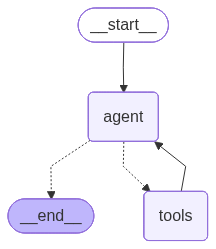

In [30]:
app